### This notebook compute "VCA15. Percentage of critical points on riverbanks or streams protected from danger" indicator for the 27 basins of IKI Project

Spanish: Porcentaje de puntos críticos en riberas de río o quebradas protegidas ante el peligro

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/12/2026 by Sophia Bakar (sbakar@rti.org)

**Status:** Complete and loaded in SQLite for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Puntos Criticos from ANA

**Outputs:** 
 
**Assumptions:** Given available information, calculation only includes the number of puntos criticos from ANA per area of COMID, not the number of puntos criticos 'atendidos' (from local government, etc.) as detailed in the annex. 
 
**Future work:** 

**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 515 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#pc_shp = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\PuntosCriticos\PuntosCriticos.shp'
pc_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\PuntosCriticos\PuntosCriticos.shp"


In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
pc_gdf = gpd.read_file(pc_shp).to_crs(subbasins_gdf.crs)

In [6]:
subbasins_gdf

,COMID,GRID_CODE,GRID_COUNT,PROD_UNIT,AREASQKM,Cuenca,grupo_mod,IDDIST,NOMBDIST,geometry
0,311153600,311152200,588,3,127.529,Cuenca Ilave,11,210112,PLATERIA,"POLYGON ((1044381.708 8220232.343, 1044438.498..."
1,310832400,310821000,435,3,189.658,Cuenca Ramis,11,210605,PUSI,"POLYGON ((1036078.636 8304636.66, 1036527.471 ..."
2,310825700,310836800,261,3,67.078,Cuenca Ramis,11,211105,SAN MIGUEL,"POLYGON ((1021175.289 8300811.869, 1021623.963..."
3,310282400,310247500,809,3,136.619,Cuenca Ica,6,110101,ICA,"POLYGON ((421294.727 8439248.725, 420844.961 8..."
4,308754600,308772100,544,3,122.208,Cuenca Mantaro,5,190104,HUAYLLAY,"POLYGON ((336025.343 8802045.383, 335569.76 88..."
...,...,...,...,...,...,...,...,...,...,...
3650,312029900,312002100,242,3,49.210,Cuenca Caplina,8,230111,LA YARADA LOS PALOS,"POLYGON ((973180.716 7983299.364, 973203.268 7..."
3651,312046300,312031700,77,3,15.652,Cuenca Caplina,8,230111,LA YARADA LOS PALOS,"POLYGON ((970564.097 7984750.223, 971447.57 79..."
3652,312066700,312047300,415,3,84.369,Intercuenca 13155,8,230111,LA YARADA LOS PALOS,"MULTIPOLYGON (((1001919.07 8000617.22, 1001907..."
3653,320251000,319228200,2130,3,434.256,Intercuenca 13155,8,230111,LA YARADA LOS PALOS,"POLYGON ((983574.448 7974718.391, 983528.11 79..."


In [7]:
# Calculate the density of features per 250 sq km for each subbasin
subbasins_pc = gpd.sjoin(subbasins_gdf, pc_gdf, how='left', predicate='intersects')
subbasins_pc_count = subbasins_pc.groupby('COMID').size().reset_index(name='PC_Count')
subbasins_pc_count = subbasins_pc_count.merge(subbasins_gdf[['COMID']], on='COMID', how='left')
subbasins_pc_gdf = subbasins_gdf.merge(subbasins_pc_count[['COMID', 'PC_Count']], on='COMID', how='left')
subbasins_pc_gdf['PC_Density'] = subbasins_pc_gdf['PC_Count'] / subbasins_pc_gdf['AREASQKM']

count    3655.000000
mean        0.071045
std         0.286084
min         0.001274
25%         0.008956
50%         0.014812
75%         0.033976
max         7.974482
Name: PC_Density, dtype: float64

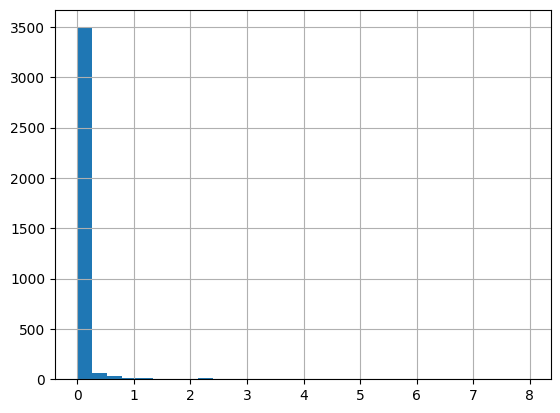

In [8]:
subbasins_pc_gdf.describe()

#histogram of value above, excluding zeros
subbasins_pc_gdf['PC_Density'][subbasins_pc_gdf['PC_Density'] > 0].hist(bins=30)

#visual summary table, excluding zeros
subbasins_pc_gdf['PC_Density'][subbasins_pc_gdf['PC_Density'] > 0].describe()

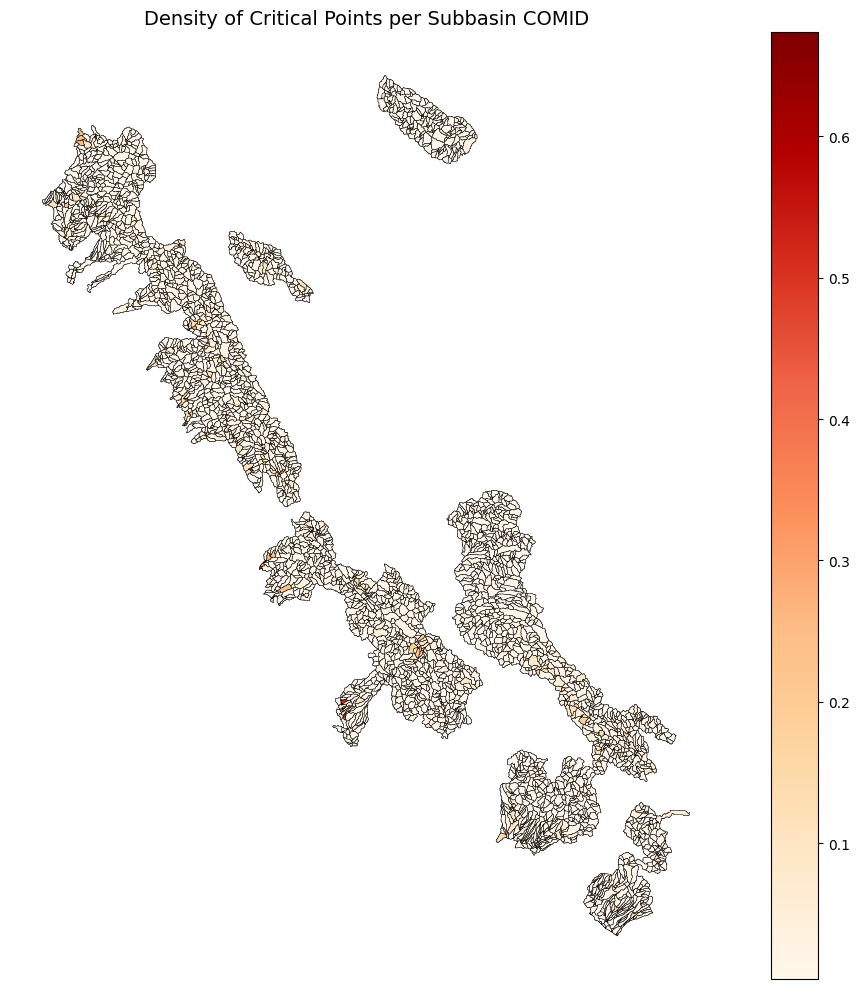

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot NaNs in light grey
subbasins_pc_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.3)

# Plot valid values with scaled colorbar
data = subbasins_pc_gdf[subbasins_pc_gdf['PC_Density'].notna()]

if not data.empty:
    vmin = data['PC_Density'].quantile(0.02)
    vmax = data['PC_Density'].quantile(0.98)
    data.plot(
        column='PC_Density',
        cmap='OrRd',
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.3
    )

ax.set_title(
    'Density of Critical Points per Subbasin COMID',
    fontsize=14
)
ax.axis('off')

plt.tight_layout()
plt.show()


SQLITE INSERT 

In [13]:
# insert results into the database 
insert_data= subbasins_pc_gdf 
value_column= 'PC_Density' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [15]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_pc_gdf['PC_Density']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 515  Min: 0, Max: 10

=== Values to be inserted (by scenario) ===
   index   PC_Density
0    min     0.001274
1    max     7.974482
2  count  3655.000000
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [16]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()